# Background tutorial

In this tutorial you will familiarize with reading DICOM images, and refresh a number of concepts regarding showing image and signal pre-processing

First thing, you'll read a 2D DICOM image, specifically chest X-rays.
Data come from the "The Society for Imaging Informatics in Medicine (SIIM) and the American College of Radiology (ACR)" pneuomothorax imaging challenge https://siim.org/page/pneumothorax_challenge
The scope was to invent an algoritm to automatically detect ("segment") a pneuomthorax area in the image, if present.

## Imports

List of libraries we will use

In [1]:
from pydicom import dcmread  # tool to read dicom files. Need to
import pydicom.errors  # in case we need to do some error handling
import os  # tools to deal with paths
import glob  # find files recursively
import numpy as np  # matrix manipulation
import matplotlib.pyplot as plt  # plotting


# Task 1: Dicom files reading and handling

Read using dcmread the file 'train/1.2.276.0.7230010.3.1.4.8323329.1000.1517875165.878027.dcm'
documentation: https://pydicom.github.io/pydicom/dev/reference/generated/pydicom.filereader.dcmread.html

Print everything that is inside and look at the headers:

Identify patient name, age, sex, body part examined

Identify the image dimensions (rows and columns)

What is the sampling spacing between the pixels? How many bits are used in each pixel?

(BTW, you can also iterate on what is returned by dcmread)

In [ ]:
dcmHead = dcmread("dicom_immTest.dcm")

print(dcmHead)

In [4]:
for ds in dcmHead:
    print(ds)

(0008, 0005) Specific Character Set              CS: 'ISO_IR 100'
(0008, 0016) SOP Class UID                       UI: Secondary Capture Image Storage
(0008, 0018) SOP Instance UID                    UI: 1.2.276.0.7230010.3.1.4.8323329.300.1517875162.258081
(0008, 0020) Study Date                          DA: '19010101'
(0008, 0030) Study Time                          TM: '000000.00'
(0008, 0050) Accession Number                    SH: ''
(0008, 0060) Modality                            CS: 'CR'
(0008, 0064) Conversion Type                     CS: 'WSD'
(0008, 0090) Referring Physician's Name          PN: ''
(0008, 103e) Series Description                  LO: 'view: AP'
(0010, 0010) Patient's Name                      PN: '88c14312-3265-4a3f-b7bb-41818107d607'
(0010, 0020) Patient ID                          LO: '88c14312-3265-4a3f-b7bb-41818107d607'
(0010, 0030) Patient's Birth Date                DA: ''
(0010, 0040) Patient's Sex                       CS: 'F'
(0010, 1010) Patient's 

## Task 1.1: Display the image

The image data are stored in the field "pixel_array", which returns a numpy array.

Think: which data format you expect? Which array shape you expect? (find this in the dicom headers)

Once you do this, show the image using matplotlib.pyplot and imshow

In [ ]:
plt.imshow(dcmHead.pixel_array)
plt.axis("off")

NameError: name 'plt' is not defined

## Task 1.2: optimize the visualization

Does this look good? 

Show the image: bigger (plt figsize parameter), in a small range, in grayscale, choosing a good colormap. Disable axis ticks (plt.axis('off')). Use the plt.imshow options cmap, vmin,vmax

Think! How many pixels is the image wide? How big can you go in showing it?


(-0.5, 1023.5, 1023.5, -0.5)

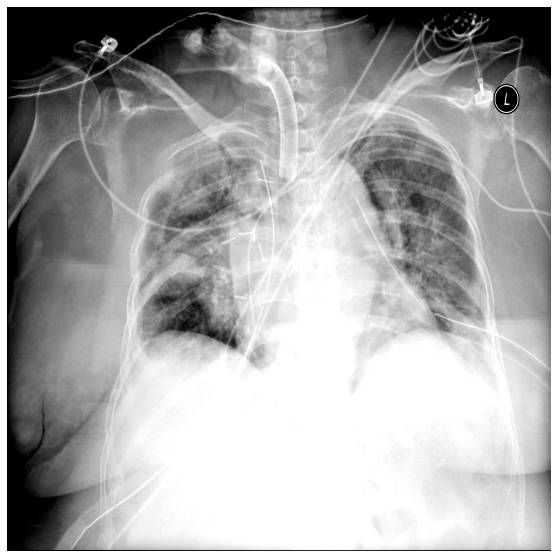

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(
    dcmHead.pixel_array, cmap="gray", vmin=50, vmax=200
)  # ,interpolation='none')
plt.axis("off")

Text(0.5, 1.0, 'Plasma')

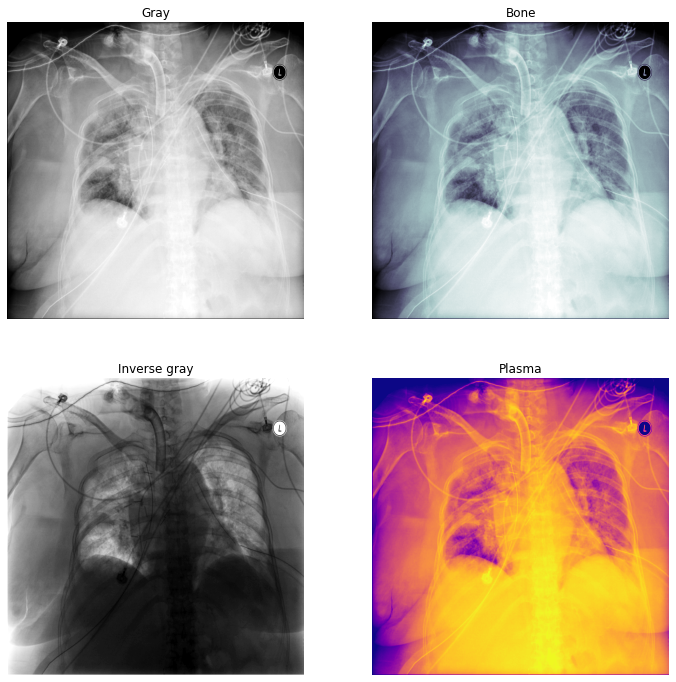

In [ ]:
plt.figure(figsize=(12, 12))
plt.subplot(221)
plt.imshow(dcmHead.pixel_array, cmap="gray", vmin=10, vmax=220)
plt.title("Gray")
plt.axis("off")
plt.subplot(222)
plt.imshow(dcmHead.pixel_array, cmap="bone", vmin=10, vmax=220)
plt.title("Bone")
plt.axis("off")
plt.subplot(223)
plt.imshow(dcmHead.pixel_array, cmap="gray_r", vmin=10, vmax=220)
plt.title("Inverse gray")
plt.axis("off")
plt.subplot(224)
plt.imshow(dcmHead.pixel_array, cmap="plasma", vmin=10, vmax=220)
plt.axis("off")
plt.title("Plasma")

The image can be successfully displayed way bigger

(400.0, 520.0, 520.0, 400.0)

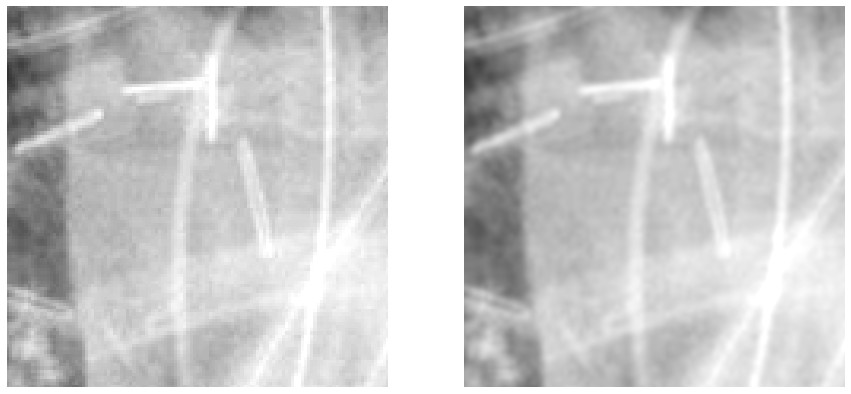

In [ ]:
plt.figure(figsize=(15, 8))
plt.subplot(121)
plt.imshow(dcmHead.pixel_array, cmap="gray", vmin=100, vmax=200, interpolation="none")
plt.xlim(400, 520)
plt.ylim(520, 400)
plt.axis("off")
plt.subplot(122)
plt.imshow(
    dcmHead.pixel_array, cmap="gray", vmin=100, vmax=200, interpolation="bicubic"
)
plt.xlim(400, 520)
plt.ylim(520, 400)
plt.axis("off")
# Even on a 10x10 inches image, a 200x200 image still show a high level of detail

It's possible to even zoom in on just 120 pixels. Interpolation makes image quality acceptable even at very high levels of zoom

# Task 2: Effects of noise, noise metrics

- Take the image, add a random vector (np.random.normal), and see what it looks like. BTW, which format is the input image? What happens if you sum np.random.normal?
- How much noise do you need to add before you notice it?
- Try displaying only a section of the image, is the impact of the same level of noise the same?
- Compute the MSE


(-0.5, 1023.5, 1023.5, -0.5)

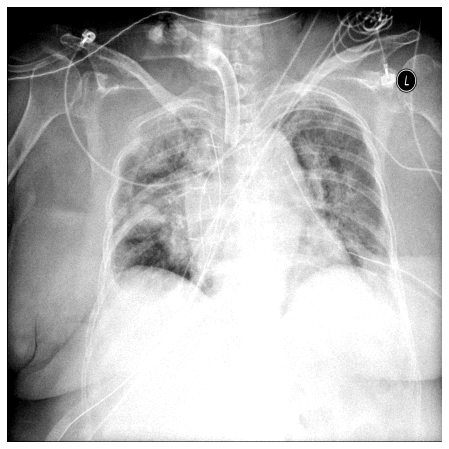

In [ ]:
immOr = dcmHead.pixel_array.copy()
immOr.dtype
immNoisy = immOr + np.random.normal(0, 10, immOr.shape)
plt.figure(figsize=(8, 8))
plt.imshow(immNoisy, cmap="gray", vmin=20, vmax=200)
# plt.xlim(400,600)
# plt.ylim(600,400)
plt.axis("off")

A high level of noise does not impact on the visibility of details when shown at lower resolution

(400.0, 600.0, 400.0, 600.0)

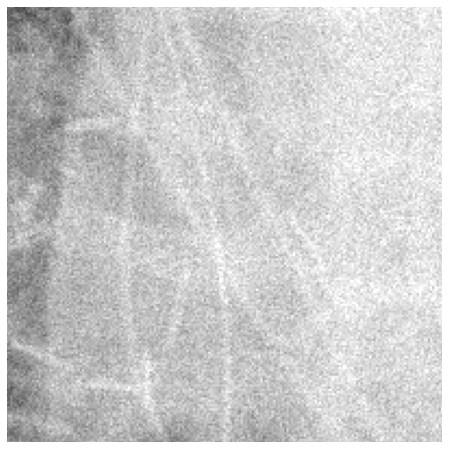

In [ ]:
plt.figure(figsize=(8, 8))
plt.imshow(immNoisy, cmap="gray", vmin=50, vmax=220)
plt.xlim(400, 600)
plt.ylim(400, 600)
plt.axis("off")

Zooming in shows that the same level of noise hides many small details

In [ ]:
print(
    "the MSE is {:.1f}".format(
        np.sum((immNoisy - immOr) ** 2, dtype=np.float32) / immNoisy.size
    )
)

the MSE is 99.8


# Task 3: Image processing, gaussian filtering

Once you are familiar with reading the image, familiarize yourself with processing images.
Let's start by denoising the image using gaussian filtering. 
Use scipy.ndimage.gaussian_filter (import scipy.ndimage as ndi)

Define the sigma parameter in mm (the function requires it in pixels). Try sigma values only smaller than 1 mm (why?)

BTW, which is the lowest sigma value that makes sense?

Compute MSE as a function of filtering strength

In [59]:
import scipy.ndimage as ndi

In [ ]:
help(ndi.gaussian_filter)

Help on function gaussian_filter in module scipy.ndimage.filters:

gaussian_filter(input, sigma, order=0, output=None, mode='reflect', cval=0.0, truncate=4.0)
    Multidimensional Gaussian filter.
    
    Parameters
    ----------
    input : array_like
        The input array.
    sigma : scalar or sequence of scalars
        Standard deviation for Gaussian kernel. The standard
        deviations of the Gaussian filter are given for each axis as a
        sequence, or as a single number, in which case it is equal for
        all axes.
    order : int or sequence of ints, optional
        The order of the filter along each axis is given as a sequence
        of integers, or as a single number. An order of 0 corresponds
        to convolution with a Gaussian kernel. A positive order
        corresponds to convolution with that derivative of a Gaussian.
    output : array or dtype, optional
        The array in which to place the output, or the dtype of the
        returned array. By de

In [ ]:
# Find the pixel size of the image
pixSize = dcmHead.PixelSpacing[0]
print(f"image pixel size is {pixSize:.3f} mm")

image pixel size is 0.139 mm


In [62]:
# Compute also the SSIM
from skimage.metrics import structural_similarity as ssim

In [ ]:
# read its documentation
help(ssim)

Help on function structural_similarity in module skimage.metrics._structural_similarity:

structural_similarity(im1, im2, *, win_size=None, gradient=False, data_range=None, channel_axis=None, multichannel=False, gaussian_weights=False, full=False, **kwargs)
    Compute the mean structural similarity index between two images.
    
    
    Parameters
    ----------
    im1, im2 : ndarray
        Images. Any dimensionality with same shape.
    win_size : int or None, optional
        The side-length of the sliding window used in comparison. Must be an
        odd value. If `gaussian_weights` is True, this is ignored and the
        window size will depend on `sigma`.
    gradient : bool, optional
        If True, also return the gradient with respect to im2.
    data_range : float, optional
        The data range of the input image (distance between minimum and
        maximum possible values). By default, this is estimated from the image
        data-type.
    channel_axis : int or None

In [ ]:
# Try different filters and show how many pixels they cover
# Remember that ssim needs to have data_range currectly set!

sigmaMMlist = [0, 0.1, 0.15, 0.2, 0.4, 0.8, 1.6]
MSEval = []
SSIMval = []

for sigma in sigmaMMlist:
    sigmaPix = sigma / pixSize
    print(f"Filtering with sigma of {sigmaPix:.1f} pixels")
    iSm = ndi.gaussian_filter(immNoisy, sigmaPix)
    iOrSm = ndi.gaussian_filter(immOr, sigmaPix)
    MSEval.append(
        [
            np.sum((iSm - immOr) ** 2, dtype=np.float32) / immNoisy.size,
            np.sum((iOrSm - immOr) ** 2, dtype=np.float32) / immNoisy.size,
        ]
    )
    SSIMval.append(
        [ssim(iSm, immOr, data_range=255), ssim(iOrSm, immOr, data_range=255)]
    )

Filtering with sigma of 0.0 pixels
Filtering with sigma of 0.7 pixels
Filtering with sigma of 1.1 pixels
Filtering with sigma of 1.4 pixels
Filtering with sigma of 2.9 pixels
Filtering with sigma of 5.8 pixels
Filtering with sigma of 11.5 pixels


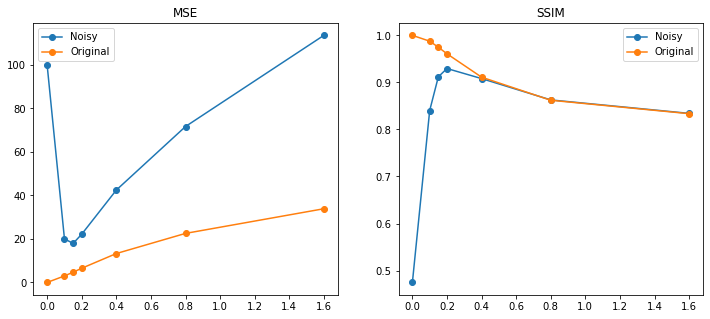

In [ ]:
## The MSE and SSIM have slightly different trends

plt.figure(figsize=(12, 5))
plt.subplot(121)
plt.plot(sigmaMMlist, np.array(MSEval), "o-")
plt.legend(["Noisy", "Original"])
plt.title("MSE")
plt.subplot(122)
plt.plot(sigmaMMlist, np.array(SSIMval), "o-")
plt.title("SSIM")
plt.legend(["Noisy", "Original"])

Show the image before and after convolution, side by side.

Can you spot the differences?

If you do not see differences, what happens if you zoom in?

### Showing the filtering with the best image quality

as measured using SSIM

In [ ]:
sigmaPix = 0.2 / pixSize
print(f"Filtering with sigma of {sigmaPix:.1f} pixels")
iSm = ndi.gaussian_filter(immNoisy, sigmaPix)
iOrSm = ndi.gaussian_filter(immOr, sigmaPix)

Filtering with sigma of 1.4 pixels


(700.0, 400.0)

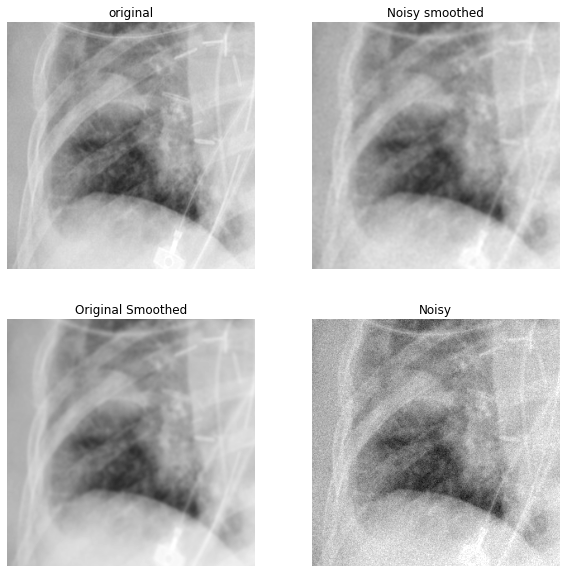

In [ ]:
plt.figure(figsize=(10, 10))
plt.subplot(221)
plt.imshow(immOr, cmap="gray", vmin=20, vmax=220)
plt.xlim(200, 500)
plt.ylim(700, 400)
plt.axis("off")
plt.title("original")
plt.subplot(222)
plt.imshow(iSm, cmap="gray", vmin=20, vmax=220)
plt.title("Noisy smoothed")
plt.axis("off")
plt.xlim(200, 500)
plt.ylim(700, 400)
plt.subplot(223)
plt.imshow(iOrSm, cmap="gray", vmin=20, vmax=220)
plt.title("Original Smoothed")
plt.axis("off")
plt.xlim(200, 500)
plt.ylim(700, 400)

plt.subplot(224)
plt.imshow(immNoisy, cmap="gray", vmin=20, vmax=220)
plt.title("Noisy")
plt.axis("off")
plt.xlim(200, 500)
plt.ylim(700, 400)

### Bonus Task: what happens if you subtract filtered and unfiltered images?

What happens if you subtract the original image from the convolved one?

1. Are you able to do the subraction? If not how can you fix that?
1. Do you see anything? If not, what do you need to tweak?
1. What do you see as a function of sigma?

(-0.5, 1023.5, 1023.5, -0.5)

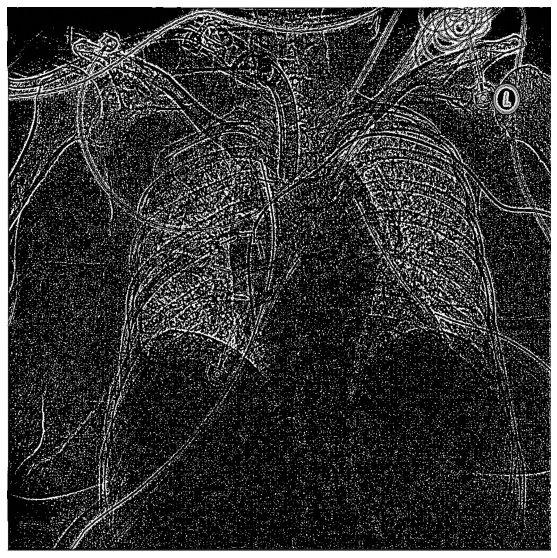

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(immOr - iOrSm, cmap="gray")
plt.axis("off")

Subtracting low-pass filtered images with the original ones leaves only edges shown

# Task 3: Resample the image


### Task 3.1: downsample the image to a 256x256
e.g.:use skimage.transform.resize or scipy.ndimage.zoom 

Go on the documentation and read the options you can pass!!


In [ ]:
import skimage

help(skimage.transform.resize)

Help on function resize in module skimage.transform._warps:

resize(image, output_shape, order=None, mode='reflect', cval=0, clip=True, preserve_range=False, anti_aliasing=None, anti_aliasing_sigma=None)
    Resize image to match a certain size.
    
    Performs interpolation to up-size or down-size N-dimensional images. Note
    that anti-aliasing should be enabled when down-sizing images to avoid
    aliasing artifacts. For downsampling with an integer factor also see
    `skimage.transform.downscale_local_mean`.
    
    Parameters
    ----------
    image : ndarray
        Input image.
    output_shape : iterable
        Size of the generated output image `(rows, cols[, ...][, dim])`. If
        `dim` is not provided, the number of channels is preserved. In case the
        number of input channels does not equal the number of output channels a
        n-dimensional interpolation is applied.
    
    Returns
    -------
    resized : ndarray
        Resized version of the input.
 

In [ ]:
iDownSample = skimage.transform.resize(immOr, [256, 256], anti_aliasing=False)

(-0.5, 255.5, 255.5, -0.5)

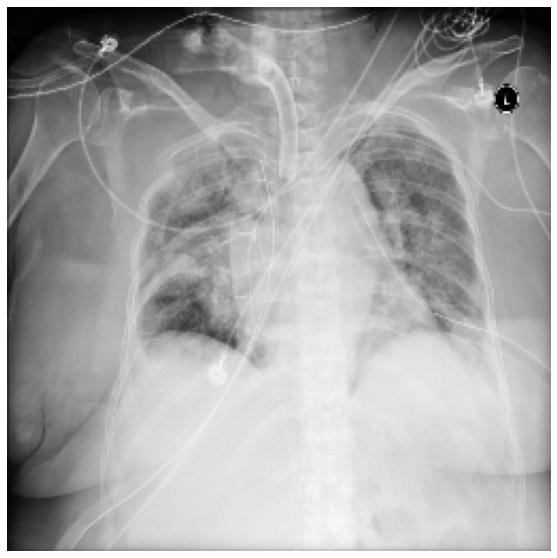

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(iDownSample, cmap="gray")
plt.axis("off")

### Task 3.2: upsample a small region of the image (e.g.: from pixel 400 to 500 along both axes) at 50x50 um^2 pixel size

Use the same functions as before

Notice how deep we can go into upsampling before we lose image quality. Think about whether this makes sense by calculating how many pixels plt.figure is using!

When displaying the image pyplot.imshow might apply interpolation. Be sure to pass the parameter "interpolation=none"

In [ ]:
round(pixSize / 0.05)

3

In [ ]:
iZoom = skimage.transform.resize(immOr[400:500, 400:500], [300, 300], order=3)
iZoom.shape

(300, 300)

Run the previous cell multiple times changing orders from 0 up to 3 to see the effect of interpolation with 0-order, linear interpolation and higher interpolation

Higher orders result in smoother edges and better perceptual quality

(-0.5, 299.5, 299.5, -0.5)

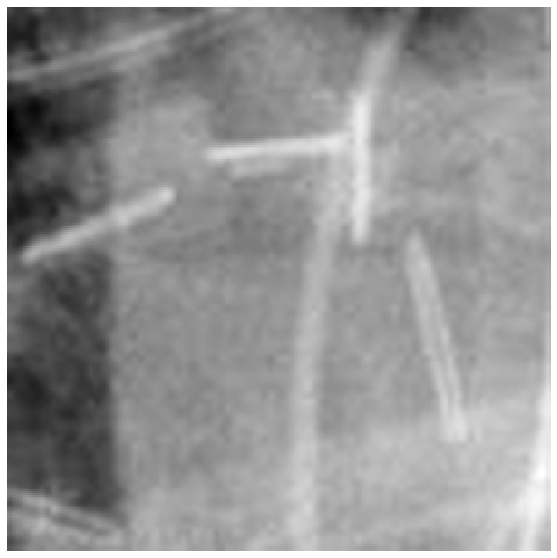

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(iZoom, cmap="gray", interpolation="none")  # ,vmin=50,vmax=200)
plt.axis("off")